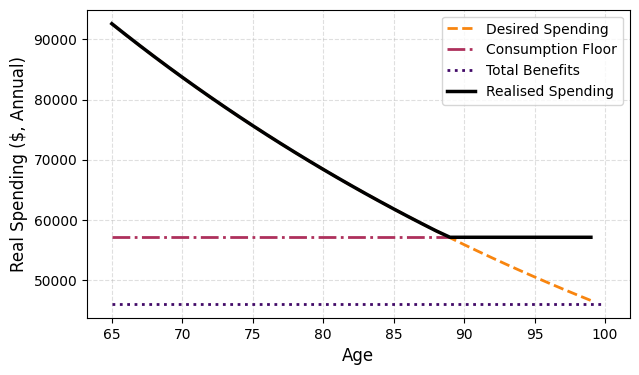

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import sys

EXPENDITURE_GUIDELINES = {
    # Singles
    "no_frills_provincial_single": 32_000.0,
    "no_frills_metro_single": 38_400.0,
    "choices_provincial_single": 47_700.0,
    "choices_metro_single": 52_800.0,
    # Couples
    "no_frills_provincial_couple": 48_300.0,
    "no_frills_metro_couple": 57_100.0,
    "choices_provincial_couple": 79_100.0,
    "choices_metro_couple": 92_600.0
}

# import utils.constants as constants
WINTER_ENERGY_COUPLE = 1_655.0  # $31.82/week * 52 weeks
NZ_SUPER_COUPLE = 44_400.0  # Couple combined

SIMULATION_YEARS = 35
DESIRED_SPENDING = EXPENDITURE_GUIDELINES['choices_metro_couple']
SPENDING_DECLINE_RATE = 0.02
CONSUMPTION_FLOOR = EXPENDITURE_GUIDELINES['no_frills_metro_couple']
FLOOR_DECLINE_RATE = 0.00


t = np.arange(0, SIMULATION_YEARS)
desired_spending_over_time = DESIRED_SPENDING * (1 - SPENDING_DECLINE_RATE) ** t
consumption_floor_over_time = CONSUMPTION_FLOOR * (1 - FLOOR_DECLINE_RATE) ** t
spending = np.maximum(desired_spending_over_time, consumption_floor_over_time)

# Use inferno colormap for consistency with other scripts
colors = cm.inferno(np.linspace(0.2, 0.999, 4))

plt.figure(figsize=(7, 4))
plt.plot(t+65, desired_spending_over_time, label='Desired Spending', linestyle='--', color=colors[2], linewidth=2)
plt.plot(t+65, consumption_floor_over_time, label='Consumption Floor', linestyle='-.', color=colors[1], linewidth=2)
plt.hlines(NZ_SUPER_COUPLE+WINTER_ENERGY_COUPLE, xmin=65, xmax=100, colors=colors[0], linestyles=':', linewidth=2, label='Total Benefits')
plt.plot(t+65, spending, label='Realised Spending', linewidth=2.5, color="black")
plt.xlabel('Age', fontsize=12)
plt.ylabel('Real Spending ($, Annual)', fontsize=12)
plt.grid(True, alpha=0.4, linestyle='--')
plt.legend()
plt.savefig('../desired_spending.png', dpi=300, bbox_inches='tight')
